In [402]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import helpers
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"


train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)

In [403]:
train = train.copy()

In [404]:
train.tail(10)

,sensor,time,power,temperature
6626918,N96,7.876138e+09,0.0,17.286369
6626919,N96,7.877002e+09,0.0,17.306267
6626920,N96,7.877866e+09,0.0,17.084299
6626921,N96,7.878730e+09,0.0,17.013214
6626922,N96,7.879594e+09,0.0,17.587847
6626923,N96,7.880458e+09,0.0,16.284252
6626924,N96,7.881322e+09,0.0,NaN
6626925,N96,7.882186e+09,0.0,16.588602
6626926,N96,7.883050e+09,0.0,16.201292
6626927,N96,7.884000e+09,0.0,17.525541


In [405]:
train.shape

(6626928, 4)

In [406]:
#sensors.plot(kind='scatter', x='coor_x', y='coor_y')

In [407]:
#train.plot(kind='scatter', x='time', y='power')

In [408]:
#train.plot(kind='scatter', x='time', y='temperature', alpha=0.3)

In [409]:
#view of possible outliers --> here we see two 'bad' sensors
#train.plot(kind='scatter', x='sensor', y='temperature')

In [410]:
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [411]:
#see if we have missing values --> some in temperature
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [412]:
#selection des sensor proches

In [413]:
train["temperature"] = train["temperature"].fillna(train["temperature"].mean()) #ici à la place de prendre le mean de tout, il faudrait prendre celui des 3-4 sensor les plus proches --> KNN

In [414]:
#control that every missing values are replaced
train.isna().any() 

sensor         False
time           False
power          False
temperature    False
dtype: bool

In [415]:
#finding number of sensors that are outliers
neg_outlier = train[train['temperature'] == train['temperature'].min()]
pos_outlier = train[train['temperature'] == train['temperature'].max()]
print(neg_outlier, pos_outlier)

        sensor          time        power  temperature
483784    N277  0.000000e+00  1487.964722  -292.150848
483785    N277  8.640000e+05  1487.288818  -292.150848
483786    N277  1.728000e+06  1486.612915  -292.150848
483787    N277  2.592000e+06  1485.936890  -292.150848
483788    N277  3.456000e+06  1485.260986  -292.150848
...        ...           ...          ...          ...
4910859   N277  7.880458e+09     0.000000  -292.150848
4910860   N277  7.881322e+09     0.000000  -292.150848
4910861   N277  7.882186e+09     0.000000  -292.150848
4910862   N277  7.883050e+09     0.000000  -292.150848
4910863   N277  7.884000e+09     0.000000  -292.150848

[27384 rows x 4 columns]         sensor          time        power  temperature
2181592   N927  0.000000e+00  1487.964722  6039.049805
2181593   N927  8.640000e+05  1487.288818  6039.049805
2181594   N927  1.728000e+06  1486.612915  6039.049805
2181595   N927  2.592000e+06  1485.936890  6039.049805
2181596   N927  3.456000e+06  1485.2609

In [416]:
#get rid of the outlier sensors
train = train[train["sensor"] != "N277"]
train = train[train["sensor"] != "N927"]

In [417]:
#verify that the outlier sensors are gone
np.all(train["sensor"] != 'N277') and np.all(train["sensor"] != 'N927')

np.True_

In [418]:
#verify that shape is coorect. it is because we removed 27'384 lines per sensor and have 2 sensors
train.shape

(6572160, 4)

In [419]:
#train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15)

In [420]:
sensors = sensors[sensors["sensor"] != "N277"]
sensors = sensors[sensors["sensor"] != "N927"]

In [421]:
sensors.shape

(323, 4)

In [ ]:
#separation modes
train = train.reset_index(drop=True)
# Nombre de timesteps par mode

BLOCK_SIZE = 9128

# Créer un index de mode (0, 1, 2) qui se répète toutes les 9128 lignes
n = len(train)
mode_index = (np.arange(n) // BLOCK_SIZE) % 3

# Séparer en 3 DataFrames
mode1 = train[mode_index == 0].copy()
mode2 = train[mode_index == 1].copy()
mode3 = train[mode_index == 2].copy()

# Vérification
print(mode1.shape, mode2.shape, mode3.shape)

(2190720, 4) (2190720, 4) (2190720, 4)
2190720.0


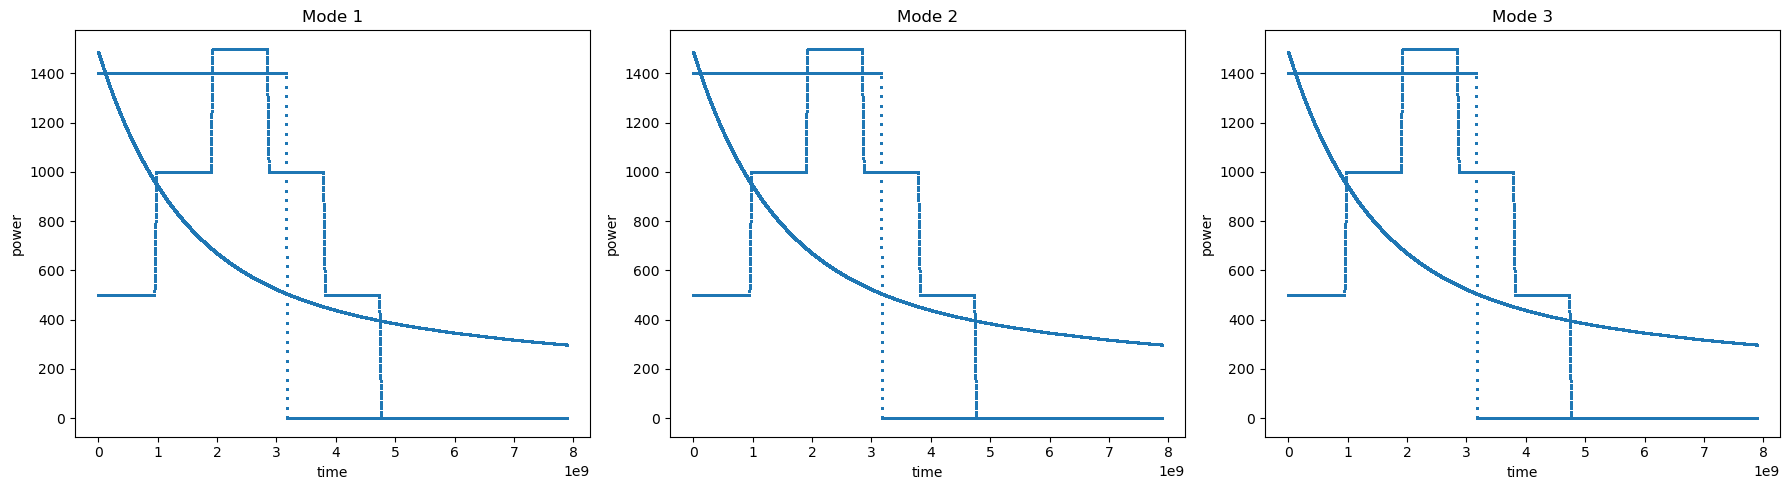

In [423]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()